In [1]:
import matplotlib.pyplot as plt
import cv2
import numpy as np
from segment_anything import sam_model_registry, SamAutomaticMaskGenerator
import torch
import math

In [2]:
# Load image
#image_path = "inaturalist_12K/train/Mammalia/0da9d10fd3085282087e1019af4fd262.jpg"  # Seal
#image_path =  "inaturalist_12K/train/Mammalia/4c99765473a3747bb3eb847d57035134.jpg" # Animal on tree
#image_path = "inaturalist_12K/train/Amphibia/1a800a65d71c838e766758cf1fefdbf8.jpg"  # Frog in hand
#image_path = "inaturalist_12K/train/Arachnida/00fecee9b14151ca32a5e33fc9437127.jpg" # A spider on a stick
#image_path = "inaturalist_12K/train/Arachnida/1a17ed46ff18f93e2724abf49c6e0499.jpg"  # A spider on its web
#image_path = "inaturalist_12K/train/Aves/0bd0de63c076d4c207032cbf990949d6.jpg"  # A bird on a tree (almost same color)
#image_path = "inaturalist_12K/train/Animalia/0e3e6943baebf61153ec41d0e6ef8b0b.jpg"  # A woodlouse or s.th. similar to that
image_path = "inaturalist_12K/train/Animalia/1aec41ba6e6713b8f5c5b321ff773fcd.jpg"  # A starfish

image = cv2.imread(image_path)[:, :, ::-1]
image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

In [3]:
# Load SAM model (use vit_b for laptop)
model_type = "vit_b"
checkpoint_path = "sam_vit_b_01ec64.pth"  # download from repo
sam = sam_model_registry[model_type](checkpoint=checkpoint_path)

In [4]:
# CPU/GPU selection
device = "cuda" if torch.cuda.is_available() else "cpu"
sam.to(device)

# Automatic mask generator
mask_generator = SamAutomaticMaskGenerator(sam,
                                          points_per_side=8,  # Change back to 32 for HPC usage
                                          pred_iou_thresh=0.9,
                                          stability_score_thresh=0.8)

# Settings for spiders
# mask_generator = SamAutomaticMaskGenerator(
#     sam,
#     points_per_side=8,
#     pred_iou_thresh=0.6,        # lower: accept imperfect masks
#     stability_score_thresh=0.3,  # lower: keep fragile structures
#     min_mask_region_area=20,      # allow small components
#     crop_n_layers=1,          # try 1–2
#     crop_n_points_downscale_factor=2,
#     points_per_batch=128
# )

In [5]:
masks = mask_generator.generate(image)

### Using scoring to determine best mask

In [6]:
# # What is the best mask? -> This method was not working so good
# h, w = image.shape[:2]
# image_area = h * w
# center = np.array([w // 2, h // 2])
#
# best_score = math.inf
# best_mask = None
#
# scores = []
#
# for m in masks:
#     mask = m["segmentation"]
#     area = m["area"]
#
#     # Compute centroid
#     ys, xs = np.where(mask)
#     if len(xs) == 0:
#         continue
#     centroid = np.array([xs.mean(), ys.mean()])
#
#     # Distance to center
#     dist = np.linalg.norm(centroid - center, ord=2)     # Euclidean norm
#
#     # Normalize area
#     area_ratio = area / image_area
#
#     # Scoring
#     score = dist * 0.001 - area_ratio * 1.0
#     # Old scoring
#     #score = area - 0.5 * dist
#     scores.append(score)
#
#     if score < best_score:
#         best_score = score
#         best_mask = mask

In [7]:
# plt.figure(figsize=(8, 8))
# plt.imshow(image)
#
# colored_mask = np.zeros((*best_mask.shape, 3))
# colored_mask[best_mask] = [1, 0, 0]
#
# plt.imshow(colored_mask, alpha=0.5)
# plt.show()

### Using CLIP to determine best mask

In [8]:
# Randomized morphological dilation
"""
The bounding box of the segmentation mask of the ocean includes the seal, so the seal will be equally detected. But the shape of the seal,
even if it is completely white, has the information of the shape of a seal. So, the ocean will likely be classified more as a seal than an ocean.
Therefore, my idea is to:
Everywhere the segmentation mask is FALSE but adjacent to a TRUE pixel: Randomly extend the mask by a bit in that direction.
So I extend the image a bit, taking small parts of the seal randomly, but not too much. The information of the shape will be noisy.
"""

"""
Source for this code:
I let AI create the function (https://chatgpt.com/, GPT-5.3 model), using the following prompt:

"I want to find the segmentation mask that fits to an animal (there are several classes). The code below does it already quite well.
It uses CLIP to predict whether the segmentation mask matches the bad or good prompts and creates a score.
One important step was to not use bounding boxes to crop the images only, but also to take out other objects.
This improved the accuracy by a bit. Imagine an ocean with a seal. The bounding box of the segmentation mask of the ocean includes the seal,
so the seal will be equally detected.

But the shape of the seal, even if it is completely white, has the information of the shape of a seal. So, the ocean will
likely be classified more as a seal than an ocean. Therefore, my idea is to:

Everywhere the segmentation mask is FALSE but adjacent to a TRUE pixel: Randomly extend the mask by a bit in that direction.
So I extend the image a bit, taking small parts of the seal randomly, but not too much. The information of the shape will be noisy.
Can you do that?

<My code so far>"
"""

def random_expand_mask(mask, max_expand=3, p=0.3, iterations=1):

    mask = mask.astype(np.uint8)
    h, w = mask.shape

    for _ in range(iterations):
        # Find boundary: pixels that are 1 and have at least one 0 neighbor
        kernel = np.ones((3, 3), np.uint8)
        eroded = cv2.erode(mask, kernel, iterations=1)
        boundary = mask - eroded  # boundary pixels

        new_mask = mask.copy()

        ys, xs = np.where(boundary > 0)

        for y, x in zip(ys, xs):
            if np.random.rand() > p:
                continue

            # random direction
            dy = np.random.randint(-1, 2)
            dx = np.random.randint(-1, 2)

            if dy == 0 and dx == 0:
                continue

            length = np.random.randint(1, max_expand + 1)

            for step in range(1, length + 1):
                ny = y + dy * step
                nx = x + dx * step

                if 0 <= ny < h and 0 <= nx < w:
                    new_mask[ny, nx] = 1

        mask = new_mask

    return mask.astype(bool)

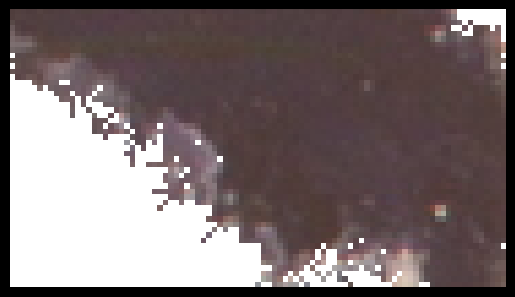

Mask 0
a photo of a watermark: 35.19%
a photo of a label: 7.65%
a close-up photo of an organism: 4.69%
a cropped background region: 4.55%
 a photo of text: 3.27%


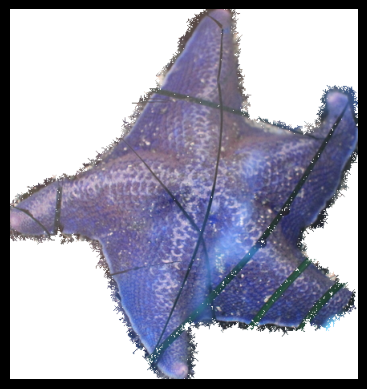

Mask 1
a photo of a mollusk: 17.14%
a close-up photo of an organism: 11.29%
a cropped background region: 10.88%
a photo of a stem: 5.50%
a photo of an animal body: 4.76%


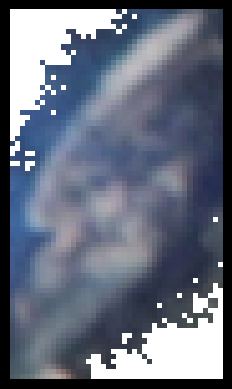

Mask 2
a cropped background region: 20.61%
a photo of a watermark: 17.18%
a photo of the background: 5.45%
 a photo of text: 5.25%
a photo of a label: 2.80%


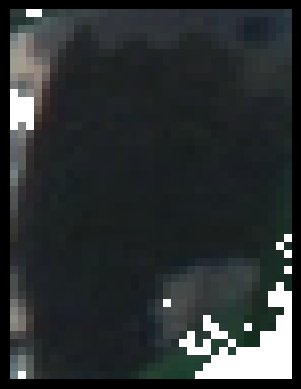

Mask 3
 a photo of text: 15.58%
a photo of a watermark: 11.55%
a photo of the background: 5.80%
a photo of a person: 4.46%
a photo of a face: 3.33%


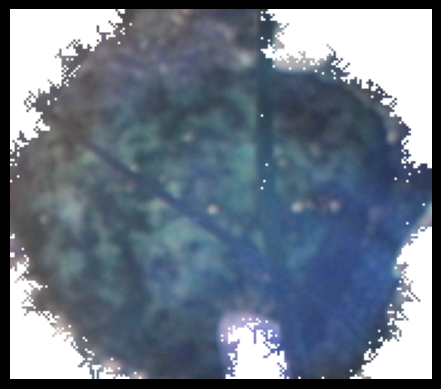

Mask 4
a photo of a watermark: 7.99%
 a photo of soil: 7.60%
a cropped background region: 5.93%
a photo of the water surface: 5.23%
a close-up photo of an organism: 4.22%


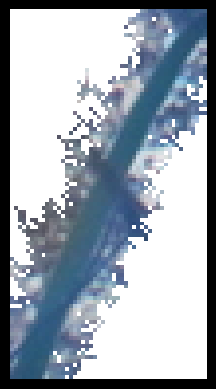

Mask 5
a photo of a watermark: 23.27%
a photo of feathers: 10.42%
a cropped background region: 8.76%
 a photo of text: 6.03%
a photo of a stem: 4.70%
Best score: 0.2594


In [12]:
# Source: https://github.com/openai/CLIP

import clip
from PIL import Image

#good_prompts = ["an animal", "aquatic mammals", "insects"]#, "a mammal", "an amphibian", "a seal"]
# good_prompts = [
#     "a photo of a seal",
#     "a photo of an animal",
#     "a photo of a mammal",
#     "a photo of a reptile",
#     "a photo of an insect",
#     "a photo of a bird",
#     "a photo of an amphibian",
#     "a photo of a frog",
#     "a photo of a spider"
# ]
good_prompts = [
    # broad foreground
    "a photo of an animal",
    "a photo of a living organism",
    "a photo of wildlife",
    "a close-up photo of an organism",

    # Animalia / generic animals
    "a photo of an animal body",
    "a photo of an animal head",
    "a photo of an animal on a white background",
    "a photo of a centipede",
    "a photo of a millipede",


    # Amphibia
    "a photo of an amphibian",
    "a photo of a frog",
    "a photo of a toad",
    "a photo of a salamander",
    #
    # Arachnida
    "a photo of an arachnid",
    "a photo of a spider",
    "a photo of a scorpion",
    #
    # Aves
    "a photo of a bird",
    "a photo of feathers",
    "a photo of a bird head",
    #
    # Fungi
    "a photo of a fungus",
    "a photo of a mushroom",
    "a photo of fungi",
    #
    # Insecta
    "a photo of an insect",
    "a photo of a beetle",
    "a photo of a butterfly",
    "a photo of a bee",
    "a photo of a fly",
    #
    # Mammalia
    "a photo of a mammal",
    "a photo of a furry animal",
    "a photo of an animal face",
    #
    # Mollusca
    "a photo of a mollusk",
    "a photo of a snail",
    "a photo of a slug",
    "a photo of a shellfish",
    #
    # Plantae
    "a photo of a plant",
    "a photo of a flower",
    "a photo of leaves",
    "a photo of a stem",
    #
    # Reptilia
    "a photo of a reptile",
    "a photo of a lizard",
    "a photo of a snake",
    "a photo of a turtle"
]

#bad_prompts = ["water", "a tree", "a hand", "background", "a person"]
# bad_prompts = [
#     "a photo of a person",
#     "a photo of a hand",
#     "a landscape",
#     "grass or forest",
#     "a photo of a lake",
#     "a photo of the ocean",
#     "a river flowing",
#     "water surface with reflections",
#     "a photo with a tree",
#     "a photo with a piece of wood"
# ]

bad_prompts = [

    # humans / artificial objects
    "a photo of a person",
    "a photo of a human hand",
    "a photo of fingers",
    "a photo of a face",
    "a photo of clothing",
    "a photo of a camera strap",
    "a photo of a cage",
    "a photo of a fence",
    "a photo of a wall",
    "a photo of a building",
    "a photo of a road",
    "a photo of a path",
    "a photo of a table",
    "a photo of a label",
    "a photo of a sign",
    "a photo of text",
    "a photo of a watermark",

    # generic background / scenery
    "a photo of a landscape",
    "a photo of scenery",
    "a blurry background",
    "an out of focus background",
    "an empty background",
    "a plain background",

    # vegetation / terrain
    "a photo of grass",
    "a photo of a forest",
    "a photo of bushes",
    "a photo of tree bark",
    "a photo of a tree branch",
    "a photo of wood",
    "a photo of dead leaves",
    "a photo of soil",
    "a photo of mud",
    "a photo of rocks",
    "a photo of sand",
    "a photo of moss",

    # water / sky
    "a photo of a lake",
    "a photo of the ocean",
    "a photo of a river",
    "a photo of water",
    "a photo of water reflections",
    "a photo of the water surface",
    "a photo of the sky",
    "a photo of blue sky",
    "a photo of clouds",

    # lighting / artifacts / false masks
    "a photo of a shadow",
    "a photo of a reflection",
    "a dark silhouette",
    "a bright light",
    "a blurry object",
    "a white background",
    "a black background",

    # frequent SAM mistakes
    "a photo of the background",
    "a cropped background region",
    "a close-up texture",
    "a patch of grass",
    "a patch of water",
    "a piece of wood",
]

text_prompts = good_prompts + bad_prompts

clip_model, preprocess = clip.load("ViT-B/32", device=device)
#image_double_check = preprocess(Image.open(image_path)).unsqueeze(0).to(device)
text = clip.tokenize(text_prompts).to(device)

with torch.no_grad():
    text_features = clip_model.encode_text(text)
    text_features /= text_features.norm(dim=-1, keepdim=True)
    # Image features in loop below

scores = []

for idx, mask_data in enumerate(masks):
    # Old version of cropping: Not good, as background contains the object as well
    #x, y, w, h = mask_data["bbox"]
    #crop = image_rgb[y:y+h, x:x+w]

    # Create mask from randomized morphological dilation
    mask = mask_data["segmentation"]
    mask = random_expand_mask(mask, max_expand=3, p=0.5, iterations=10)

    # Create white background (black not so good, as CLIP has seen many silouettes of animals, which appear dark)
    masked_image = np.ones_like(image_rgb) * 255

    # Keep only mask pixels
    masked_image[mask] = image_rgb[mask]

    # Crop to bbox AFTER masking (better computation time for CLIP)
    x, y, w, h = mask_data["bbox"]
    crop = masked_image[y:y+h, x:x+w]

    plt.imshow(crop)
    plt.axis("off")
    plt.show()

    if crop.size == 0:
        scores.append(-1)
        continue

    pil_img = Image.fromarray(crop)
    img_input = preprocess(pil_img).unsqueeze(0).to(device)

    with torch.no_grad():
        image_features = clip_model.encode_image(img_input)
        image_features /= image_features.norm(dim=-1, keepdim=True)

    # cosine similarity
    similarity = image_features @ text_features.T  # shape: [1, N]

    # Option 1: Take best matching prompt -> Not good
    #score = similarity.max().item()

    # Option 2: Penalize unwanted classes
    #animal_score = similarity[0, :len(good_prompts)].max()
    #non_animal_score = similarity[0, len(good_prompts):].max()
    #score = (animal_score - non_animal_score).item()

    # Option 3: Softmax
    probs = (100.0 * similarity).softmax(dim=-1)
    score = probs[0, :len(good_prompts)].sum() - probs[0, len(good_prompts):].sum()

    scores.append(score)

    print(f"Mask {idx}")
    values, indices = probs[0].topk(5)
    for value, index in zip(values, indices):
        print(f"{text_prompts[index]:>16s}: {100 * value.item():.2f}%")

best_idx = int(np.argmax(scores))
best_mask = masks[best_idx]["segmentation"]

print(f"Best score: {scores[best_idx]:.4f}")

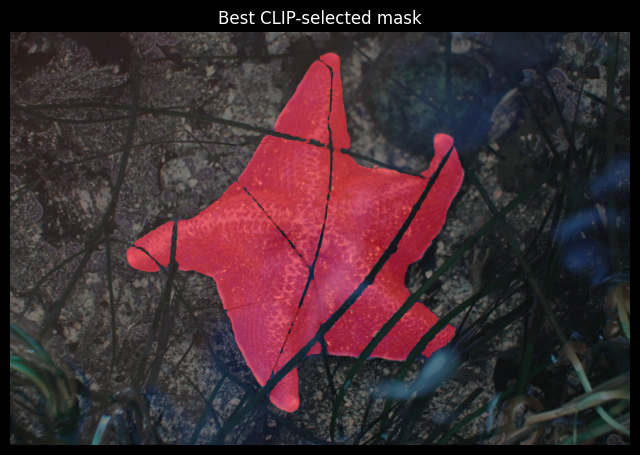

In [13]:
plt.figure(figsize=(8, 6))
#best_mask = masks[1]["segmentation"]

plt.imshow(image_rgb)

colored_mask = np.zeros((*best_mask.shape, 3))
colored_mask[best_mask] = [1, 0, 0]

# overlay mask
plt.imshow(colored_mask, alpha=0.5)

plt.title("Best CLIP-selected mask")
plt.axis("off")
plt.show()